In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Load the block model data
df = pd.read_csv('block_model.csv')

# Establish a baseline carbon price for feature calculation ($/tonne)
base_carbon_price = 50.0

# Feature Engineering: Calculate carbon cost per block
# Feature A: Carbon Intensity (GHG per tonne of ore)
df['carbon_intensity'] = df['ghg_kg_co2_per_t']

# Feature B: Net Revenue after Carbon
# carbon penalty per tonne 
df['carbon_cost_per_t'] = (df['ghg_kg_co2_per_t'] / 1000) * base_carbon_price

# Net Revenue = Revenue - Mining - Processing - Carbon Penalty
df['net_revenue_after_carbon'] = (
    df['revenue_per_t'] - 
    df['mining_cost_t'] - 
    df['processing_cost_t'] - 
    df['carbon_cost_per_t']
)

# Target Variable for the ML model: Environmental Cost per block
# Calculate absolute total environmental cost per block
df['total_ghg_tonnes'] = df['ghg_kg_co2_per_t'] * df['tonnage_kt']
df['target_environmental_cost'] = df['total_ghg_tonnes'] * base_carbon_price

print("\nPreview of new features:")
print(df[['block_id', 'carbon_intensity', 'net_revenue_after_carbon', 'target_environmental_cost']].head())


Preview of new features:
  block_id  carbon_intensity  net_revenue_after_carbon  \
0    B0000             26.02                   72.3090   
1    B0001             31.26                   67.1770   
2    B0002             28.57                   94.1315   
3    B0003             25.26                  104.1670   
4    B0004             29.41                   76.4695   

   target_environmental_cost  
0                  746123.50  
1                  836048.70  
2                  517974.10  
3                  531596.70  
4                  698046.35  


In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Define features (X) and target (y)

feature_columns = [
    'carbon_intensity', 
    'net_revenue_after_carbon', 
    'tonnage_kt', 
    'ore_grade_pct', 
    'waste_ratio'
]

X = df[feature_columns]
y = df['target_environmental_cost']

# 2. Split the data (80% for training, 20% for testing the model's accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Random Forest
print("Training Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Make Predictions on the unseen Test data
y_pred = rf_model.predict(X_test)

# 5. Evaluate the Model's Performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) 
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-Squared (R²) Score: {r2:.4f}")

Training Random Forest Regressor...

--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): $11,980.89
Root Mean Squared Error (RMSE): $18,245.42
R-Squared (R²) Score: 0.9878


In [3]:
# 6.Compare actual vs predicted for a few test blocks
results_df = pd.DataFrame({
    'Actual_Environmental_Cost': y_test,
    'Predicted_Cost': y_pred,
    'Error': abs(y_test - y_pred)
})
print("\n--- Actual vs Predicted (First 5 blocks) ---")
print(results_df.head().to_string())


--- Actual vs Predicted (First 5 blocks) ---
     Actual_Environmental_Cost  Predicted_Cost       Error
361                 1004007.25     985183.4425  18823.8075
73                   560502.40     561697.3040   1194.9040
374                  567758.00     564483.8990   3274.1010
155                  610144.15     597298.6595  12845.4905
104                  553430.50     551281.5485   2148.9515


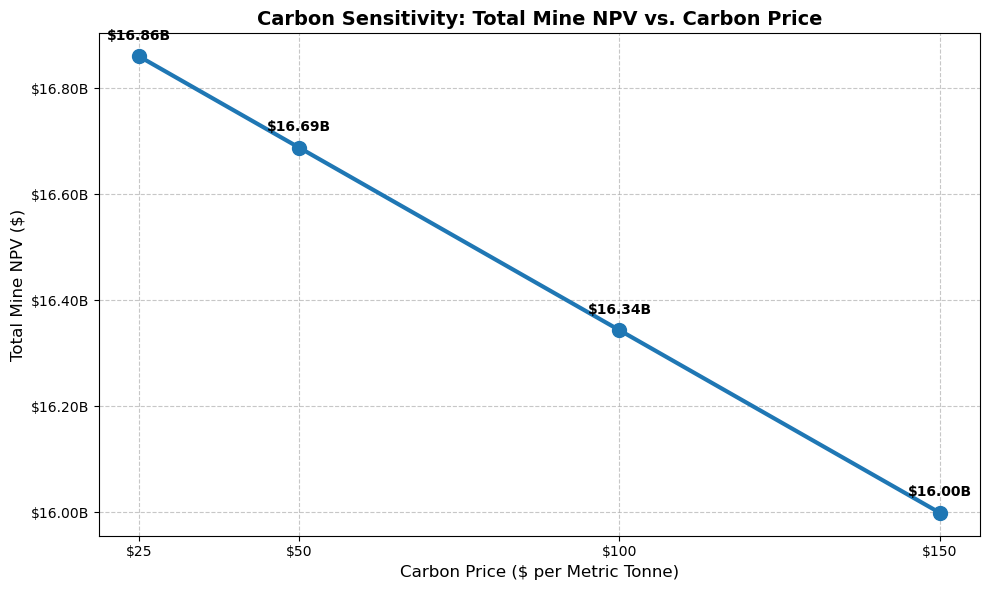

In [4]:
import matplotlib.pyplot as plt

# test prices scenarios
test_prices = [25, 50, 100, 150]
total_npv_results = []

# Base profit of the mine
# The 'npv_per_t' column represents base profit (revenue - mining - processing) per tonne.
# We multiply by (tonnage_kt * 1000) to get the total base profit for each block.
df['total_base_npv'] = df['npv_per_t'] * (df['tonnage_kt'] * 1000)
mine_base_npv = df['total_base_npv'].sum()

# --- 3. Sensitivity Loop: Test each carbon price ---
for price in test_prices:
    # Calculate the total carbon penalty for the entire mine at this specific price
    # Note: df['total_ghg_tonnes'] was already calculated in Cell 1
    total_carbon_penalty = (df['total_ghg_tonnes'] * price).sum()
    
    # New Mine NPV = Base Profit - Carbon Penalty
    new_npv = mine_base_npv - total_carbon_penalty
    total_npv_results.append(new_npv)

# --- 4. Plotting the Carbon Sensitivity Chart ---
plt.figure(figsize=(10, 6))

# Create a thick line plot with clear markers
plt.plot(test_prices, total_npv_results, marker='o', markersize=10, linewidth=3, color='#1f77b4')

# Chart Formatting
plt.title('Carbon Sensitivity: Total Mine NPV vs. Carbon Price', fontsize=14, fontweight='bold')
plt.xlabel('Carbon Price ($ per Metric Tonne)', fontsize=12)
plt.ylabel('Total Mine NPV ($)', fontsize=12)

# Ensure the X-axis only shows our specific test prices
plt.xticks(test_prices, [f'${p}' for p in test_prices])
plt.grid(True, linestyle='--', alpha=0.7)

# Format the Y-axis neatly in Billions ($B)
def billions_formatter(x, pos):
    return f'${x / 1e9:.2f}B'
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(billions_formatter))

# Add exact data labels directly above each point on the chart
for i, txt in enumerate(total_npv_results):
    plt.annotate(f"${txt/1e9:.2f}B", 
                 (test_prices[i], total_npv_results[i]), 
                 textcoords="offset points", 
                 xytext=(0,12), 
                 ha='center',
                 fontweight='bold')

plt.tight_layout()
plt.show()

How Carbon Pricing Changes Block Economics
1. Direct Reduction of Net Profit Margins
The most immediate effect is that the carbon price acts as a direct financial penalty on the energy intensity of a block. Because your engineered feature is Net Revenue = Revenue - Mining Cost - Processing Cost - Carbon Cost, as the carbon price scales from $25 up to $150 per tonne, the profit margin of every single block shrinks. The severity of this shrinkage is directly tied to the block's specific carbon_intensity (GHG/t ore).

In [5]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid to search over

param_grid = {
    'n_estimators': [100, 200, 300],          # How many trees in the forest?
    'max_depth': [None, 10, 20, 30],          # How deep can each tree grow?
    'min_samples_split': [2, 5, 10],          # Min blocks needed to split a branch
    'min_samples_leaf': [1, 2, 4]             # Min blocks allowed at the very end of a branch
}

#base model
rf_base = RandomForestRegressor(random_state=42)

# cv=3 means 3-fold cross-validation. 
# n_jobs=-1 tells your computer to use all available CPU cores to speed up the math.
print("Starting Grid Search...")
grid_search = GridSearchCV(
    estimator=rf_base, 
    param_grid=param_grid, 
    cv=3, 
    n_jobs=-1, 
    scoring='neg_mean_absolute_error', 
    verbose=1
)

# --- 3. Execute the Search ---
grid_search.fit(X_train, y_train)

# --- 4. Extract and Evaluate the Champion Model ---
best_rf_model = grid_search.best_estimator_

print("\n Tuning Complete!")
print(f"Best Hyperparameters Discovered: {grid_search.best_params_}")

# Make new predictions with the optimized model
y_pred_opt = best_rf_model.predict(X_test)

# Calculate new metrics
mae_opt = mean_absolute_error(y_test, y_pred_opt)
rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_opt))
r2_opt = r2_score(y_test, y_pred_opt)

print("\n OPTIMIZED Model Metrics")
print(f"Optimized MAE: ${mae_opt:,.2f}")
print(f"Optimized RMSE: ${rmse_opt:,.2f}")
print(f"Optimized R² Score: {r2_opt:.4f}")

Starting Grid Search...
Fitting 3 folds for each of 108 candidates, totalling 324 fits

 Tuning Complete!
Best Hyperparameters Discovered: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

 OPTIMIZED Model Metrics
Optimized MAE: $11,379.07
Optimized RMSE: $17,276.40
Optimized R² Score: 0.9891


In [6]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Initialize the XGBoost Regressor

print("Training XGBoost Regressor...")
xgb_model = xgb.XGBRegressor(
    n_estimators=200,          # Number of sequential trees
    learning_rate=0.1,         # Step size shrinkage to prevent overfitting
    max_depth=6,               # Maximum depth of a tree
    random_state=42,
    objective='reg:squarederror' # Standard objective for regression tasks
)

# 2. Train the Model

xgb_model.fit(X_train, y_train)

# 3. Make Predictions on the Test Set
y_pred_xgb = xgb_model.predict(X_test)

# 4. Evaluate the Model 
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\n XGBoost Model Metrics")
print(f"XGBoost MAE: ${mae_xgb:,.2f}")
print(f"XGBoost RMSE: ${rmse_xgb:,.2f}")
print(f"XGBoost R² Score: {r2_xgb:.4f}")

# 5. Quick Comparison 
print("\n Model Comparison")
print(f"Random Forest MAE: ${mae_opt:,.2f}  vs.  XGBoost MAE: ${mae_xgb:,.2f}")

Training XGBoost Regressor...

 XGBoost Model Metrics
XGBoost MAE: $11,960.01
XGBoost RMSE: $17,013.47
XGBoost R² Score: 0.9894

 Model Comparison
Random Forest MAE: $11,379.07  vs.  XGBoost MAE: $11,960.01


In [7]:
!pip install shap

   ---------------------------------------- 0.0/547.2 kB ? eta -:--:--
   ---------------------------------------- 547.2/547.2 kB 9.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --------------- ------------------------ 1.0/2.7 MB 5.0 MB/s eta 0:00:01
   --------------------------- ------------ 1.8/2.7 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------  2.6/2.7 MB 4.1 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 3.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/28.1 MB ? eta -:--:--
    --------------------------------------- 0.5/28.1 MB 3.4 MB/s eta 0:00:09
   - -------------------------------------- 1.3/28.1 MB 3.9 MB/s eta 0:00:07
   --- ------------------------------------ 2.4/28.1 MB 4.2 MB/s eta 0:00:07
   ----- ---------------------------------- 3.7/28.1 MB 4.6 MB/s eta 0:00:06
   ------ --------------------------------- 4.7/28.1 MB 4.7 MB/s eta 0:00:06
   -------- ---------

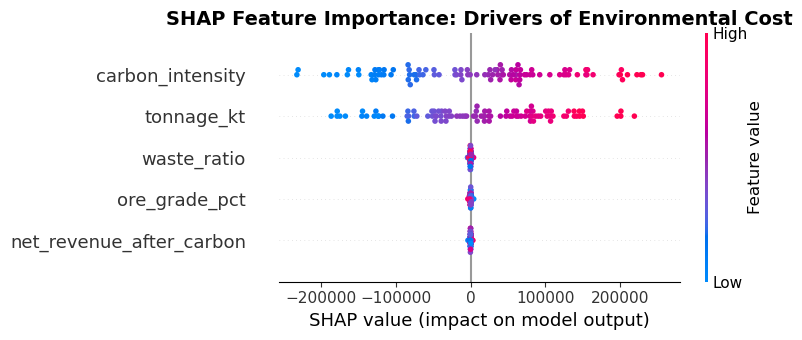

In [9]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the SHAP explainer using your trained XGBoost model
explainer = shap.TreeExplainer(best_rf_model)
shap_values = explainer.shap_values(X_test)

# 2. Generate the SHAP Summary Plot
plt.figure(figsize=(10, 6))
plt.title("SHAP Feature Importance: Drivers of Environmental Cost", fontsize=14, fontweight='bold')

# The summary plot automatically ranks features by their impact on the prediction
shap.summary_plot(shap_values, X_test, show=False)

plt.tight_layout()
plt.show()

This is a SHAP Feature Importance Bar Chart

tonnage_kt & carbon_intensity: These two features completely dominate the model's decision-making process.